Title: ERA5_data_source_Comparison.ipynb

Purpose: 

Author: Onno Nennecke on 25.04.2025 Modified: 29.04.2025

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import glob
import re
import pandas as pd


# Importing functions
import Functions.grid_func as grid_func


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


### Load ERA5 Data from ppfleiderer

In [2]:
variable = 't2m'
variables = ['u100', 'v100', 'ssrd', 't2m', 'tmax'] # List of variables
# path = f'/climca/data/ERA5/daily/{variables[3]}/' # Only for tmax und zum checken der anderen Variablen
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
year_range = (2012, 2020)


In [3]:
# List all files
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

# filtered_files


In [4]:
# Read all listed files
files_by_variable = {}

# Group files by variable name
for f in filtered_files:
    match = re.search(r'/([^/]+)_(\d{4})\.nc$', f)
    if match:
        var = match.group(1)
        if var not in files_by_variable:
            files_by_variable[var] = []
        files_by_variable[var].append(f)

files_by_variable
# SSRD_list = files_by_variable['SSRD']
# SSRD_list

# Read datasets for each variable
datasets_by_variable = {}
for var, files in files_by_variable.items():
    ds = xr.open_mfdataset(sorted(files), combine='by_coords')
    ds_daily = ds.resample(time='1D').mean()
    datasets_by_variable[var] = ds_daily

datasets_by_variable

{'SSRD': <xarray.Dataset> Size: 23MB
 Dimensions:  (time: 3288, lat: 37, lon: 47)
 Coordinates:
   * lon      (lon) float64 376B 3.0 3.3 3.6 3.9 4.2 ... 15.6 15.9 16.2 16.5 16.8
   * lat      (lat) float64 296B 45.15 45.45 45.75 46.05 ... 55.35 55.65 55.95
   * time     (time) datetime64[ns] 26kB 2012-01-01 2012-01-02 ... 2020-12-31
 Data variables:
     var169   (time, lat, lon) float32 23MB dask.array<chunksize=(1, 37, 47), meta=np.ndarray>
 Attributes:
     CDI:          Climate Data Interface version 2.0.3 (https://mpimet.mpg.de...
     Conventions:  CF-1.6
     institution:  European Centre for Medium-Range Weather Forecasts
     history:      Wed Apr 03 17:39:34 2024: cdo -f nc -remapnn,U100_2023.nc S...
     CDO:          Climate Data Operators version 2.0.3 (https://mpimet.mpg.de...,
 'U100': <xarray.Dataset> Size: 23MB
 Dimensions:  (time: 3288, lat: 37, lon: 47)
 Coordinates:
   * lon      (lon) float64 376B 3.0 3.3 3.6 3.9 4.2 ... 15.6 15.9 16.2 16.5 16.8
   * lat      (lat)

In [5]:
datasets_by_variable['SSRD'] # var169
datasets_by_variable['U100'] # var246
datasets_by_variable['V100'] # var247
datasets_by_variable['tas']  # var167

<xarray.Dataset> Size: 23MB
Dimensions:  (time: 3288, lat: 37, lon: 47)
Coordinates:
  * lon      (lon) float64 376B 3.0 3.3 3.6 3.9 4.2 ... 15.6 15.9 16.2 16.5 16.8
  * lat      (lat) float64 296B 45.15 45.45 45.75 46.05 ... 55.35 55.65 55.95
  * time     (time) datetime64[ns] 26kB 2012-01-01 2012-01-02 ... 2020-12-31
Data variables:
    var167   (time, lat, lon) float32 23MB dask.array<chunksize=(1, 37, 47), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.0.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Apr 03 17:32:44 2024: cdo -f nc -sellonlatbox,3,17,56,4...
    CDO:          Climate Data Operators version 2.0.3 (https://mpimet.mpg.de...

In [6]:
# Combine all datasets into a single dataset
var_names = {'var169': 'rsds',
             'var167': 'tas',
             'var246': 'U100',
             'var247': 'V100'}

ds_list = []

for i in datasets_by_variable:
    # print(i)
    # print(datasets_by_variable[i])
    # print('------------------')
    ds = datasets_by_variable[i]
    var = list(ds.data_vars)[0]
    ds = ds.rename({var: var_names[var]})
    ds = ds.sel(lat=slice(45, 60), lon=slice(5, 17))
    nc = grid_func.regrid(ds)
    # Append to list for later merging
    ds_list.append(nc)
    # ds.to_netcdf(f'/climca/people/onennecke/ERA5/{i}.nc')

# Read in tmax

# Combine all into a single dataset
clim_ds = xr.merge(ds_list)

In [7]:
clim_ds['wind_speed'] = np.sqrt(clim_ds['U100']**2 + clim_ds['V100']**2)
# clim_ds['tas'] = clim_ds['tas'] - 273.15
# clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15

ERA_5_pp = clim_ds

### Load ERA5 Data from climca data

In [8]:
# Code only for tasmax and for checking the other variables
year_range = (2012, 2020)

variable = 't2m' # tmax # 'u100'
base_path = '/climca/data/ERA5/daily'
# months = [10,11,12,1,2,3,4,5,6,7,8,9]  # List of months to filter (1-12)
path = os.path.join(base_path, variable, '*')
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]

# Convert month list to strings with zero padding
# if months:
#     months = [f"{int(m):02d}" for m in months]

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})-(\d{2})', file)
    if match:
        year = int(match.group(1))
        if (year_range is None or year_range[0] <= year <= year_range[1]):
            filtered_files.append(file)

filtered_files = sorted(filtered_files)
filtered_files
nc = xr.open_mfdataset(filtered_files)
nc = nc.sel(lat=slice(60, 45), lon=slice(5, 17))
nc = grid_func.regrid(nc)
nc

<xarray.Dataset> Size: 2MB
Dimensions:   (time: 3288, lat: 10, lon: 12)
Coordinates:
  * time      (time) datetime64[ns] 26kB 2012-01-01T11:30:00 ... 2020-12-31T1...
  * lat       (lat) int64 80B 47 48 49 50 51 52 53 54 55 56
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 96B 5 6 7 8 9 10 11 12 13 14 15 16
Data variables:
    var167    (time, lat, lon) float32 2MB dask.array<chunksize=(1, 10, 12), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

### Plotting

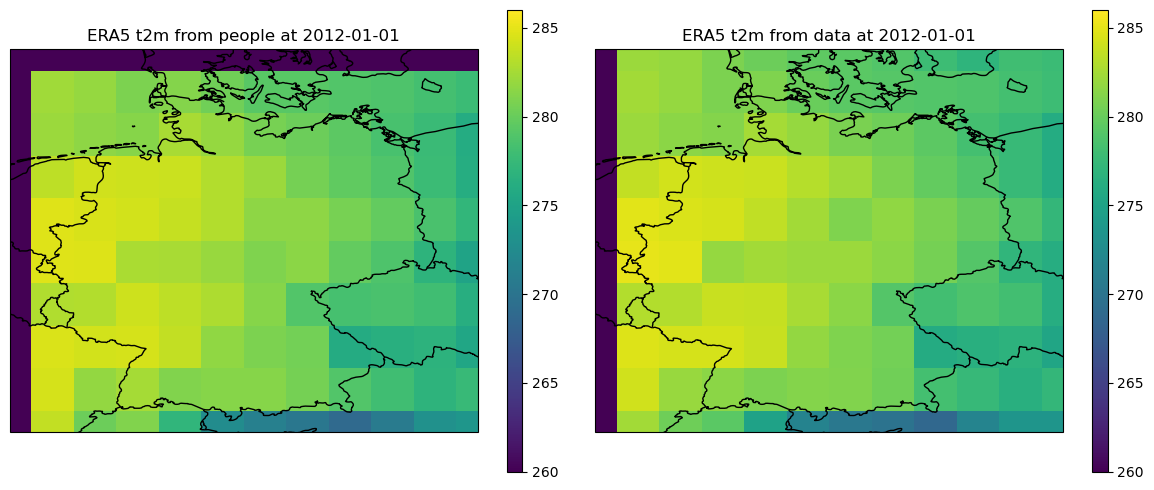

In [9]:
# Define your custom colormap and value range
cmap = 'viridis'
vmin = 260
vmax = 286

# Extract time strings
time1 = str(ERA_5_pp.time[0].values)[:10]
time2 = str(nc.time[0].values)[:10]

# Create figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Common extent and feature setup
extent = [5, 16, 47, 56]

# First subplot: ERA_5_pp
axs[0].set_extent(extent, crs=ccrs.PlateCarree())
lon1 = ERA_5_pp.lon
lat1 = ERA_5_pp.lat
t2m_1 = ERA_5_pp.tas[0, :, :].values
contour1 = axs[0].pcolormesh(lon1, lat1, t2m_1, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)
axs[0].add_feature(cfeature.COASTLINE, zorder=1, edgecolor='black')
axs[0].add_feature(cfeature.BORDERS, zorder=1, edgecolor='black')
axs[0].set_title(f'ERA5 t2m from people at {time1}')
plt.colorbar(contour1, ax=axs[0], orientation='vertical', pad=0.05, aspect=30)

# Second subplot: nc
axs[1].set_extent(extent, crs=ccrs.PlateCarree())
lon2 = nc.lon
lat2 = nc.lat
t2m_2 = nc.var167[0, :, :].values
contour2 = axs[1].pcolormesh(lon2, lat2, t2m_2, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)
axs[1].add_feature(cfeature.COASTLINE, zorder=1, edgecolor='black')
axs[1].add_feature(cfeature.BORDERS, zorder=1, edgecolor='black')
axs[1].set_title(f'ERA5 t2m from data at {time2}')
plt.colorbar(contour2, ax=axs[1], orientation='vertical', pad=0.05, aspect=30)

plt.tight_layout()
plt.show()


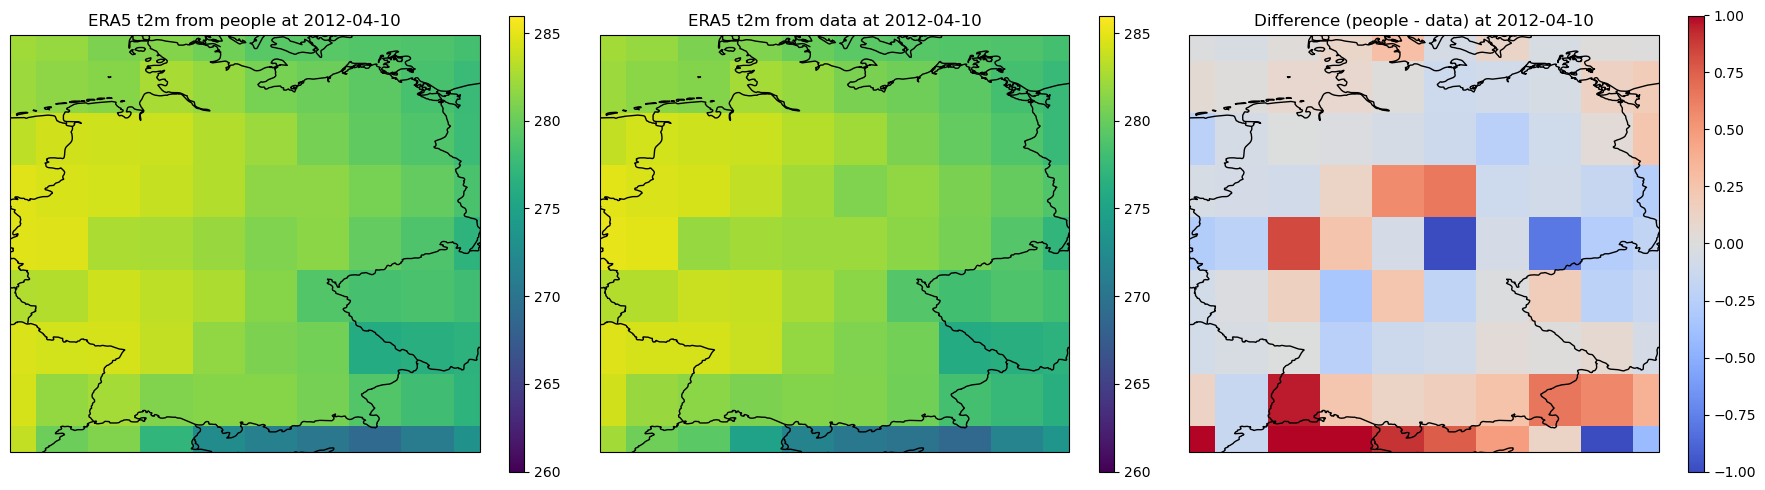

In [10]:
# Define your custom colormap and value range
cmap = 'viridis'
vmin = 260
vmax = 286

# Colormap settings for the difference plot
diff_cmap = 'coolwarm'
diff_vmin = -1  # Adjust depending on expected range of differences
diff_vmax = 1

t = 100

# Extract time strings
time1 = str(ERA_5_pp.time[t].values)[:10]
time2 = str(nc.time[t].values)[:10]

# Create figure and subplots (3 subplots now)
fig, axs = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Common extent and feature setup
extent = [6, 15, 47, 55]

# First subplot: ERA_5_pp
axs[0].set_extent(extent, crs=ccrs.PlateCarree())
lon1 = ERA_5_pp.lon
lat1 = ERA_5_pp.lat
t2m_1 = ERA_5_pp.tas[0, :, :].values
contour1 = axs[0].pcolormesh(lon1, lat1, t2m_1, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)
axs[0].add_feature(cfeature.COASTLINE, zorder=1, edgecolor='black')
axs[0].add_feature(cfeature.BORDERS, zorder=1, edgecolor='black')
axs[0].set_title(f'ERA5 t2m from people at {time1}')
plt.colorbar(contour1, ax=axs[0], orientation='vertical', pad=0.05, aspect=30)

# Second subplot: nc
axs[1].set_extent(extent, crs=ccrs.PlateCarree())
lon2 = nc.lon
lat2 = nc.lat
t2m_2 = nc.var167[0, :, :].values
contour2 = axs[1].pcolormesh(lon2, lat2, t2m_2, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)
axs[1].add_feature(cfeature.COASTLINE, zorder=1, edgecolor='black')
axs[1].add_feature(cfeature.BORDERS, zorder=1, edgecolor='black')
axs[1].set_title(f'ERA5 t2m from data at {time2}')
plt.colorbar(contour2, ax=axs[1], orientation='vertical', pad=0.05, aspect=30)

# Third subplot: difference (people - data)
axs[2].set_extent(extent, crs=ccrs.PlateCarree())
# Calculate difference
t2m_diff = t2m_1 - t2m_2
contour3 = axs[2].pcolormesh(lon1, lat1, t2m_diff, transform=ccrs.PlateCarree(), cmap=diff_cmap, vmin=diff_vmin, vmax=diff_vmax)
axs[2].add_feature(cfeature.COASTLINE, zorder=1, edgecolor='black')
axs[2].add_feature(cfeature.BORDERS, zorder=1, edgecolor='black')
axs[2].set_title(f'Difference (people - data) at {time1}')
plt.colorbar(contour3, ax=axs[2], orientation='vertical', pad=0.05, aspect=30)

plt.tight_layout()
plt.show()


### Check specific pixels

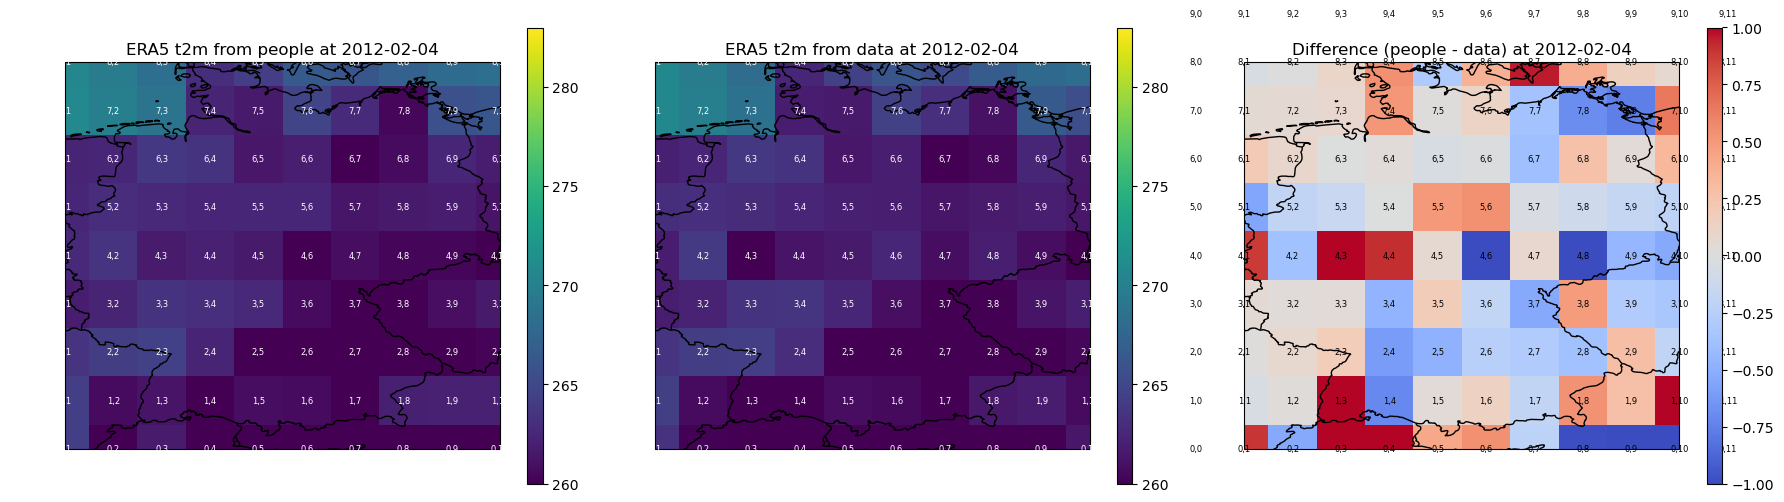

In [11]:
# Define your custom colormap and value range
cmap = 'viridis'
vmin = 260
vmax = 283

# Colormap settings for the difference plot
diff_cmap = 'coolwarm'
diff_vmin = -1  # Adjust depending on expected range of differences
diff_vmax = 1

t = 34

# Extract time strings
time1 = str(ERA_5_pp.time[t].values)[:10]
time2 = str(nc.time[t].values)[:10]

# Create figure and subplots (3 subplots now)
fig, axs = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Common extent and feature setup
extent = [6, 15, 47, 55]

# First subplot: ERA_5_pp
axs[0].set_extent(extent, crs=ccrs.PlateCarree())
lon1 = ERA_5_pp.lon.values
lat1 = ERA_5_pp.lat.values
t2m_1 = ERA_5_pp.tas[t, :, :].values

contour1 = axs[0].pcolormesh(lon1, lat1, t2m_1, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)
axs[0].add_feature(cfeature.COASTLINE, zorder=1, edgecolor='black')
axs[0].add_feature(cfeature.BORDERS, zorder=1, edgecolor='black')
axs[0].set_title(f'ERA5 t2m from people at {time1}')
plt.colorbar(contour1, ax=axs[0], orientation='vertical', pad=0.05, aspect=30)

# Annotate each cell with index (row, col)
for i in range(len(lat1)):
    for j in range(len(lon1)):
        axs[0].text(lon1[j], lat1[i], f'{i},{j}', 
                    color='white', fontsize=6, ha='center', va='center', 
                    transform=ccrs.PlateCarree())

# Second subplot: nc
axs[1].set_extent(extent, crs=ccrs.PlateCarree())
lon2 = nc.lon.values
lat2 = nc.lat.values
t2m_2 = nc.var167[t, :, :].values

contour2 = axs[1].pcolormesh(lon2, lat2, t2m_2, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax)
axs[1].add_feature(cfeature.COASTLINE, zorder=1, edgecolor='black')
axs[1].add_feature(cfeature.BORDERS, zorder=1, edgecolor='black')
axs[1].set_title(f'ERA5 t2m from data at {time2}')
plt.colorbar(contour2, ax=axs[1], orientation='vertical', pad=0.05, aspect=30)

# Annotate each cell for second plot
for i in range(len(lat2)):
    for j in range(len(lon2)):
        axs[1].text(lon2[j], lat2[i], f'{i},{j}', 
                    color='white', fontsize=6, ha='center', va='center', 
                    transform=ccrs.PlateCarree())

# Third subplot: difference (people - data)
axs[2].set_extent(extent, crs=ccrs.PlateCarree())
# Calculate difference
t2m_diff = t2m_1 - t2m_2
contour3 = axs[2].pcolormesh(lon1, lat1, t2m_diff, transform=ccrs.PlateCarree(), cmap=diff_cmap, vmin=diff_vmin, vmax=diff_vmax)
axs[2].add_feature(cfeature.COASTLINE, zorder=1, edgecolor='black')
axs[2].add_feature(cfeature.BORDERS, zorder=1, edgecolor='black')
axs[2].set_title(f'Difference (people - data) at {time1}')
plt.colorbar(contour3, ax=axs[2], orientation='vertical', pad=0.05, aspect=30)

# Annotate each cell for difference plot
for i in range(len(lat1)):
    for j in range(len(lon1)):
        axs[2].text(lon1[j], lat1[i], f'{i},{j}', 
                    color='black', fontsize=6, ha='center', va='center', 
                    transform=ccrs.PlateCarree())

plt.tight_layout()
plt.show()


In [12]:
t2m_diff

array([[ 0.00000000e+00,  8.91632080e-01, -5.35125732e-01,
         1.64630127e+00,  1.46363831e+00,  4.26940918e-01,
         5.46142578e-01, -2.22045898e-01, -9.86297607e-01,
        -2.15963745e+00, -2.66213989e+00, -5.63812256e-01],
       [ 0.00000000e+00, -3.96118164e-02,  1.56250000e-02,
         1.75891113e+00, -7.15148926e-01,  3.54309082e-02,
         1.34582520e-01, -1.93237305e-01,  5.31951904e-01,
         2.76428223e-01,  1.42697144e+00,  4.48883057e-01],
       [ 0.00000000e+00,  1.33361816e-02,  7.49816895e-02,
         1.80786133e-01, -6.10626221e-01, -4.86358643e-01,
        -2.56286621e-01, -2.96783447e-01, -3.76434326e-01,
         2.91442871e-01, -1.97418213e-01, -1.55334473e-02],
       [ 0.00000000e+00,  5.81665039e-02,  2.74963379e-02,
         3.71704102e-02, -4.75860596e-01,  1.91406250e-01,
        -1.84722900e-01, -5.33782959e-01,  4.84832764e-01,
        -2.96051025e-01, -3.30352783e-01, -1.04156494e-01],
       [ 0.00000000e+00,  8.76739502e-01, -3.8189697

In [13]:

t2m_diff.flatten().max()

import numpy as np

# Find the flattened index of the max value
flat_index = np.argmax(t2m_diff)

# Now convert that flat index back to 2D indices
row, col = np.unravel_index(flat_index, t2m_diff.shape)

print(f'Max value is at (row={row}, col={col})')
print(f'Max value: {t2m_diff[row, col]}')


Max value is at (row=4, col=3)
Max value: 4.08258056640625


### Timeseries comparison at one location

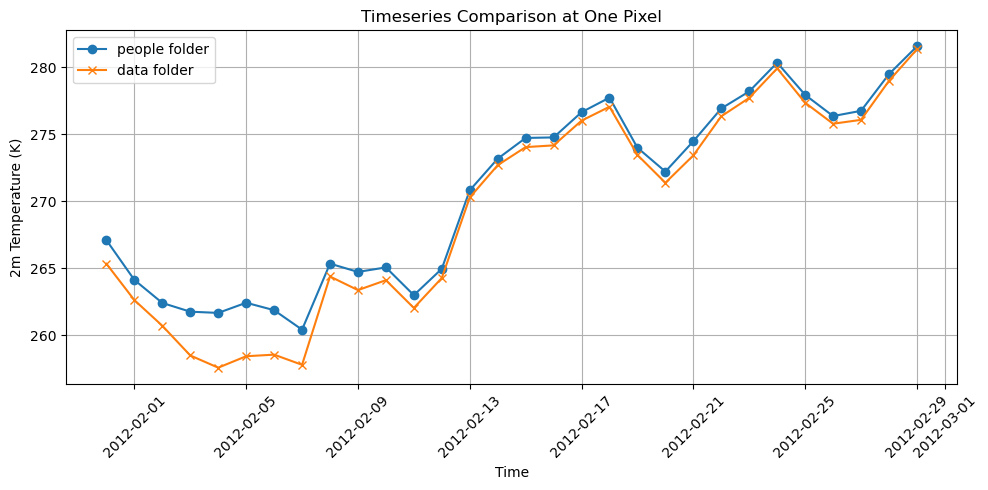

In [14]:
# Pick a pixel somewhere in the middle
mid_lat_idx = 4# len(ERA_5_pp.lat) // 2 +2

mid_lon_idx = 3# len(ERA_5_pp.lon) // 2+2

# Extract the timeseries for that pixel
# times_era = ERA_5_pp.time
times_era = pd.to_datetime(ERA_5_pp.time.values).normalize()  # normalize to remove hours
pixel_era = ERA_5_pp.tas[:, mid_lat_idx, mid_lon_idx]

# times_nc = nc.time
times_nc = pd.to_datetime(nc.time.values).normalize()  # normalize to remove hours
pixel_nc = nc.var167[:, mid_lat_idx, mid_lon_idx]

# Select roughly one month
start_day = 30
end_day = 60  # 30 days for a month
times_era_month = times_era[start_day:end_day]
pixel_era_month = pixel_era[start_day:end_day]

times_nc_month = times_nc[start_day:end_day]
pixel_nc_month = pixel_nc[start_day:end_day]

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_era_month, pixel_era_month, label='people folder', marker='o')
ax.plot(times_nc_month, pixel_nc_month, label='data folder', marker='x')

ax.set_xlabel('Time')
ax.set_ylabel('2m Temperature (K)')
ax.set_title('Timeseries Comparison at One Pixel')
ax.legend()
ax.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [15]:
mid_lat_idx
mid_lon_idx
times_nc[34]

Timestamp('2012-02-04 00:00:00')

In [16]:
print(pixel_era_month[20].values)
print(pixel_nc_month[20].values)
print(pixel_era_month[4].values - pixel_nc_month[4].values)


272.20932
271.37595
4.0825806
